In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import multiprocessing
import os
import pickle

try:
    cores = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
    print(f"Number of cores: {cores}")
except:
    cores = multiprocessing.cpu_count()


os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(cores)

import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from astropy.table import Table
from gpjax.kernels import RBF, Linear, Periodic, White, Matern12, Matern32, Matern52
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from tensorflow_probability.substrates.jax.distributions import Normal
from tqdm import tqdm

from gallifrey.inference import log_likelihood_function
from gallifrey.kernels import OrnsteinUhlenbeck
from gallifrey.kernelsearch import (
    KernelSearch,
    describe_kernel,
    set_trainables,
    get_trainables,
)
from gallifrey.mcmc import nuts_warmup, run_mcmc

In [3]:
jax.config.update("jax_enable_x64", True)
rng_key = jax.random.PRNGKey(42)

## Load Data

In [4]:
model_name = "hats46b_gpmodel"

df = (
    Table.read("../data/external/HATS_46b.fit")
    .to_pandas()
    .drop(columns=["FWB20", "e_FWB20"])  # not used in paper
)

t = df["Time"].to_numpy()
t_min = np.amin(t)
t -= t_min

# spectroscopic and white light curves, initial entry is white lc
y = df.iloc[:, 1::2].to_numpy().T
yerr = df.iloc[:, 2::2].to_numpy().T

# mask out transit
mask = np.ones_like(t, dtype=bool)
mask[7:41] = False

# reference parameter and limb darkening parameter, first entry is white lc
reference = pd.read_csv("../data/external/HATS_46b_reference.csv").set_index(
    df.columns[1::2]
)

## Get GP models for all light curves

In [5]:
kernel_library = [
    Linear(),
    RBF(),
    Periodic(),
    White(),
    Matern12(),
    Matern32(),
    Matern52(),
]

In [6]:
gps = []
for i in range(len(y)):
    tree = KernelSearch(
        kernel_library,
        X=jnp.array(t[mask]),
        y=jnp.array(y[i][mask]),
        obs_stddev=jnp.amax(yerr[i][mask]),
        verbosity=0,
        criterion="aic",
    )

    model = tree.search(
        depth=7,
        n_leafs=2,
        patience=0,
    ).posterior
    gps.append(model)
    print(f"Dataset {i}: {describe_kernel(model)}")


for i in range(len(y)):
    with open(
        f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
        "wb",
    ) as file:
        pickle.dump(gps[i], file)

Dataset 0: Periodic
Dataset 1: Periodic + Linear
Dataset 2: Matérn12
Dataset 3: Matérn52
Dataset 4: Matérn12
Dataset 5: Matérn32
Dataset 6: Matérn12
Dataset 7: RBF
Dataset 8: Matérn12
Dataset 9: RBF
Dataset 10: Matérn52
Dataset 11: Matérn32
Dataset 12: RBF
Dataset 13: Matérn12
Dataset 14: RBF
Dataset 15: Matérn52
Dataset 16: RBF
Dataset 17: RBF
Dataset 18: RBF
Dataset 19: Matérn12 + White • Linear
Dataset 20: Matérn12
Dataset 21: Periodic
Dataset 22: Periodic + White • Linear • Linear
Dataset 23: Matérn12 + White • Linear
Dataset 24: RBF + White
Dataset 25: RBF + White • Linear


In [7]:
# gps = []
# for i in range(len(y)):
#     with open(
#         f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}", "rb"
#     ) as file:
#         gps.append(pickle.load(file))

## Fit white curve parameter

In [8]:
def white_lc_model(t, params):
    central = orbits.keplerian.Central(
        mass=params[0],
        radius=params[1],
    )

    # The light curve calculation requires an orbit
    orbit = orbits.keplerian.Body(
        central=central,
        period=4.7423749,
        radius=params[4] * central.radius,
        inclination=jnp.deg2rad(params[2]),
        time_transit=params[3],
    )

    lc = LimbDarkLightCurve([params[5], reference["u2"]["FWL"]]).light_curve(orbit, t=t)
    return lc


white_lc_log_likelihood = log_likelihood_function(
    gps[0],
    white_lc_model,
    t,
    y[0],
    mask,
    fix_gp=False,
    compile=True,
    negative=True,
)

x0 = {
    "gp_parameter": get_trainables(gps[0], unconstrain=True),
    # host_star_mass, host_star_radius, inclination, time_transit, planet radius, u1
    "lc_parameter": jnp.array([0.869, 0.894, 86.97, 0.075, 0.09773, 0.547]),
}
white_lc_solve = ScipyMinimize(fun=white_lc_log_likelihood, method="l-bfgs-b").run(x0)
white_lc_parameter = white_lc_solve.params["lc_parameter"]

## Define LC model

In [9]:
def get_lc_model(u2):
    def lc_model(t, params):
        central = orbits.keplerian.Central(
            mass=white_lc_parameter[0],
            radius=white_lc_parameter[1],
        )

        # The light curve calculation requires an orbit
        orbit = orbits.keplerian.Body(
            central=central,
            period=3.9501907,
            radius=params[0] * central.radius,
            inclination=jnp.deg2rad(white_lc_parameter[2]),
            time_transit=white_lc_parameter[3],
        )

        lc = LimbDarkLightCurve([params[1], u2]).light_curve(orbit, t=t)
        return lc

    return lc_model

## Define likelihood, prior, posterior

In [10]:
def get_logprob(gp_model, y, u1, u2, initial_position=None, fix_gp=False):
    if initial_position is None:
        initial_position = {
            "gp_parameter": get_trainables(gp_model, unconstrain=True),
            "lc_parameter": jnp.array([0.12, u1]),
        }

    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.2 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=initial_position["lc_parameter"],
            scale=[0.2, 0.05],
        ),
    }

    # define light curve model
    lc_model = jit(get_lc_model(u2))

    log_likelihood = log_likelihood_function(
        gp_model,
        lc_model,
        t,
        y,
        mask,
        fix_gp=fix_gp,
        compile=True,
    )

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(params["lc_parameter"])
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## Fits

In [11]:
parameter_solutions = []
for i in tqdm(range(len(y))):
    log_probability, initial_position = get_logprob(
        gps[i],
        y[i],
        reference["u1"].iloc[i],
        reference["u2"].iloc[i],
    )
    solve = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)),
        method="l-bfgs-b",
    ).run(initial_position)
    parameter_solutions.append(solve.params)

100%|██████████| 26/26 [01:08<00:00,  2.62s/it]


Kernel Summary

Kernel Structure: RBF + White • Linear
with obs_stddev = 2.27126e-03 (Trainable : False)

Kernel               Property             Value                Trainable 
--------------------------------------------------------------------------------
RBF                 lengthscale          5.42337e+05          True      

                    variance             9.99994e-01          True      
--------------------------------------------------------------------------------
White               variance             1.86443e-04          True      
--------------------------------------------------------------------------------
Linear              variance             1.00000e+00          False     
--------------------------------------------------------------------------------



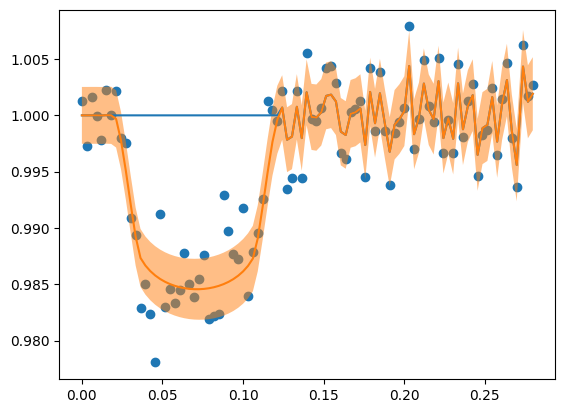

In [12]:
import matplotlib.pyplot as plt
from gallifrey.kernelsearch import kernel_summary
from gallifrey.inference import calculate_predictive_dist

i = 25
lc_model = get_lc_model(reference["u2"].iloc[i])(
    t, parameter_solutions[i]["lc_parameter"]
)

t_linspace = jnp.linspace(t.min(), t.max(), 1000)

gp_dist = calculate_predictive_dist(
    set_trainables(
        gps[i],
        parameter_solutions[i]["gp_parameter"],
        unconstrain=True,
    ).constrain(),
    t,
    x=t[mask],
    y=y[i][mask],
)

predictive_mean = gp_dist.mean()
predictive_std = gp_dist.stddev()

kernel_summary(
    set_trainables(
        gps[i], parameter_solutions[i]["gp_parameter"], unconstrain=True
    ).constrain()
)

plt.scatter(t, y[i])
plt.plot(t, predictive_mean)
plt.plot(t, lc_model + predictive_mean)
plt.fill_between(
    t,
    predictive_mean + lc_model + predictive_std,
    predictive_mean + lc_model - predictive_std,
    alpha=0.5,
)

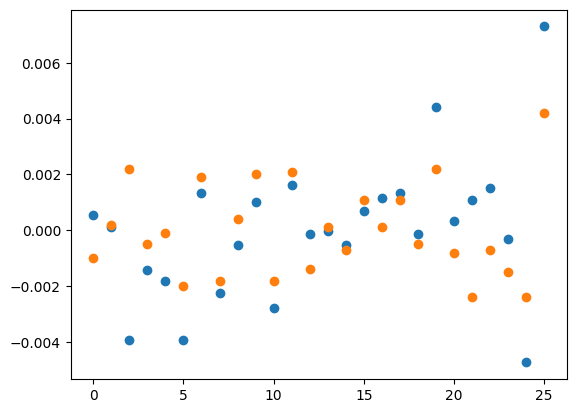

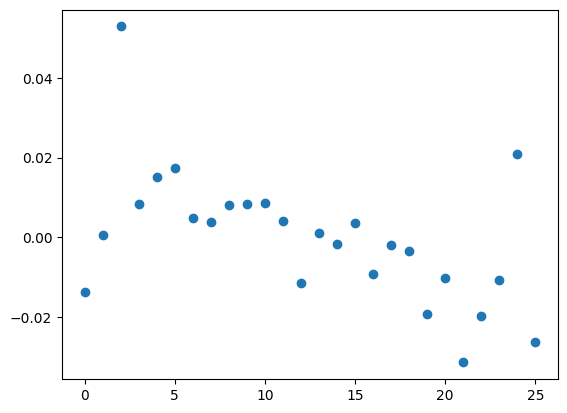

In [13]:
import matplotlib.pyplot as plt

Rps = np.array([sol["lc_parameter"][0] for sol in parameter_solutions])
plt.scatter(range(len(y)), Rps - np.mean(Rps))
plt.scatter(range(len(y)), reference["Rp"].to_numpy() - np.mean(reference["Rp"]))

plt.figure()
plt.scatter(
    range(len(y)),
    ((reference["Rp"].to_numpy() - np.mean(reference["Rp"])) - (Rps - np.mean(Rps)))
    / reference["Rp"],
)

## Run MCMC

In [14]:
num_adapt = 200
num_samples = 100
num_chains = cores

fix_gp = False

In [15]:
chains = {"gp_parameter": [], "lc_parameter": []}

for i in tqdm(range(len(y))):
    log_probability, initial_position = get_logprob(
        gps[i],
        y[i],
        reference["u1"].iloc[i],
        reference["u2"].iloc[i],
        initial_position=parameter_solutions[i],
        fix_gp=fix_gp,
    )

    # run nuts adaption
    rng_key, warmup_key = jax.random.split(rng_key, 2)
    state, parameters = nuts_warmup(
        warmup_key,
        log_probability,
        initial_position,
        num_steps=num_adapt,
        progress_bar=False,
    )

    # define initial positions and add scatter
    initial_positions = {}
    for key, value in initial_position.items():
        rng_key, scatter_key = jax.random.split(rng_key)
        initial_positions[key] = jnp.tile(
            value, (num_chains, 1)
        ) + 0.05 * value * jax.random.normal(
            scatter_key, shape=(num_chains, value.size)
        )

    rng_key, sample_key = jax.random.split(rng_key, 2)

    final_state, state_history, info_history = run_mcmc(
        sample_key,
        log_probability,
        parameters,
        initial_positions,
        num_steps=num_samples,
    )

    for par in ["gp_parameter", "lc_parameter"]:
        chain = np.array(state_history.position[par])
        chains[par].append(chain)

    # for i in range(len(y)):
    np.savez(
        f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
        **{key: chains[key][i] for key in chains.keys()},
    )

100%|██████████| 26/26 [2:52:29<00:00, 398.06s/it]  


In [34]:
np.percentile(
    np.array(chains["lc_parameter"]).reshape(26, num_samples * num_chains, 2),
    [16, 50, 84],
    axis=1,
).shape

ValueError: cannot reshape array of size 41600 into shape (26,2600,2)

In [33]:
np.array(chains["lc_parameter"]).shape

(26, 8, 100, 2)

In [35]:
np.array(chains["lc_parameter"])

array([[[[0.11217061, 0.54043681],
         [0.11065654, 0.56346412],
         [0.11236276, 0.54821184],
         ...,
         [0.11388997, 0.53757335],
         [0.11115273, 0.53861325],
         [0.1139    , 0.55411724]],

        [[0.11104491, 0.51763182],
         [0.11399768, 0.53855816],
         [0.11033703, 0.59824906],
         ...,
         [0.10913079, 0.56588061],
         [0.11408048, 0.51549158],
         [0.11251507, 0.48638572]],

        [[0.11281221, 0.62377027],
         [0.11408005, 0.59076995],
         [0.11222286, 0.52246834],
         ...,
         [0.11262172, 0.52776982],
         [0.11065385, 0.52801648],
         [0.11177573, 0.5591417 ]],

        ...,

        [[0.11479405, 0.49904378],
         [0.10894984, 0.61414371],
         [0.11568631, 0.57384344],
         ...,
         [0.11239944, 0.58895883],
         [0.11178192, 0.61989364],
         [0.11258405, 0.57711981]],

        [[0.1132559 , 0.53128533],
         [0.11238384, 0.54535716],
         [0.